### Figure 2

This code generates Figure 2 of the paper. <br>
<br>
INPUT:<br>
processed/ExpDecayConst_params.csv : Parameters for two-state model for each dataset<br>
processed/Compiled_accessible_target_ChIP_peaks.csv: Cumulative positional distribution of<br>
TF binding events
<br>
<br>
OUTPUT: <br>
Table1.csv <br>
Figure2.pdf <br>



In [1]:
## Load required modules and functions
import os 
import pandas as pd
import numpy as np
from plotnine import *
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from math import exp,log
from scipy.stats import norm
from utils import *
from sklearn.metrics import r2_score
import patchworklib as pw
from random import choices
from sklearn.linear_model import LinearRegression
import math
from sklearn.metrics import *

#Set fontsize and point size for figures
font_size = 44
point_size = 6

#Set working directory
working_dir ="TF_Positional_Distribution_Model/data/ENCODE/"
os.chdir(working_dir)

<Figure size 72x72 with 0 Axes>

### Load model parameters and cumulative binding data

In [3]:
#Load compiled peak distribution and parameters for each fit
params= pd.read_csv('processed/ExpDecayConst_params.csv', index_col =0)
df= pd.read_csv('processed/Compiled_accessible_target_ChIP_peaks.csv', index_col =0)

#Merge parameters for each cell line
df = df.merge(params,on=['TF','CellLine'])

## Table 1

In [4]:
table1 = params
table1[['TF','CellLine','rb','tau','rs']].to_csv('processed/Table1.csv')

## Effect of varying biologically relevant binding rate scaling factor (r_s)

In [25]:
vary_rs = []
for rs in np.linspace(0, 3, 5):
    vary_rs+=[[i,j,rs] for i,j in zip(model(np.linspace(0,10000,101), 18, 400, rs),
                                   np.linspace(0,10000,101))]
vary_rs = pd.DataFrame(vary_rs, columns = ['CalledPeaks', 'x','rs'])
vary_rs.rs = pd.Categorical(vary_rs.rs) 

#Calculate threshold within which 95% of biologically relevant binding occurs (based on tau)
cut= -np.log(0.05)*400

ai = (ggplot(vary_rs)
+ geom_point(aes(x='x/1000', y= 'CalledPeaks/1000'), size = point_size)
+ theme_classic()
+xlab('Distance from TSS (kbp)')
+ylab('Number of peaks\n(thousands)')
+geom_segment(aes(x = 5, y = 2, xend = 7.5, yend = 38),
                  arrow = arrow(angle=30,length=0.02,type = 'closed'))
+ annotate('text', x=6.5, y = 35, label='$r_s$', size= font_size)
+ annotate('text', x=3.200, y = 30, label='$r_b$ = 18\n $tau$ = 400', size= font_size)
+ scale_fill_discrete(guide=False)
+geom_vline(xintercept = cut/1000, colour="red", linetype = "dashed", size=2)
+ theme(figure_size=(12,8), text=element_text(size=font_size), panel_spacing = 10))



## Effect of varying biologically relevant binding rate scaling factor (r_b)

In [27]:

vary_rb = []
for rb in np.linspace(10, 50, 5):
    vary_rb+=[[i,j,rb] for i,j in zip(model(np.linspace(0,10000,101), rb, 400, 0),
                                   np.linspace(0,10000,101))]
vary_rb = pd.DataFrame(vary_rb, columns = ['CalledPeaks', 'x','rb'])
vary_rb.rb = pd.Categorical(vary_rb.rb)

#Calculate threshold within which 95% of biologically relevant binding occurs (based on tau)
cut = -np.log10(0.05)*400

aii = (ggplot(vary_rb)
+ geom_point(aes(x='x/1000', y= 'CalledPeaks/1000'), size = point_size)
+ theme_classic()
+xlab('Distance from TSS (kbp)')
+ylab('Number of peaks\n(thousands)')
+geom_segment(aes(x = 5.000, y = 2, xend = 7.500, yend = 25),
                  arrow = arrow(angle=30,length=0.02,type = 'closed'))
+ annotate('text', x=6.500, y = 23, label='$r_b$', size= font_size)
+ annotate('text', x=3.00, y = 23, label='$r_s$ = 0\n $tau$ = 400', size= font_size)
+ scale_fill_discrete(guide=False)
+geom_vline(xintercept = cut/1000, colour="red", linetype = "dashed", size=2)
+ theme(figure_size=(12,8), text=element_text(size=font_size), panel_spacing = 10))



### Visualize cumulative binding events and predicted fits for 5 TFs in 3 cell lines 

In [28]:
#Calculate expected number of biologically relevant binding events at each distance
df['Estimated true'] = df.apply(lambda x: model_true(x.interval,x.rb,x.tau,x.rs), axis =1 )

#Estimate predicted fits at each distance from TSS
df['Fit'] = df.apply(lambda x: model(x.interval,x.rb,x.tau,x.rs),  axis =1 )

#Calculate threshold within which 95% of biologically relevant binding occurs
df['95_true'] = df.apply(lambda x: -np.log(0.05) * x.tau , axis =1)



In [29]:
tfs = ['CTCF','MYC','MAX','MAZ','SIN3A']

#Calculate average threhsold value across all TFs in A549
cut= df.loc[df.CellLine == 'A549'].groupby(['TF'])['95_true'].mean().mean()

bi=(ggplot(df.loc[(df.CellLine == 'A549') & (df.TF.isin(tfs))])
+ geom_line(aes(x='interval/1000', y= 'cumulative/1000', color = 'TF'), size = 4)
+geom_line(aes(x='interval/1000', y= 'Fit/1000', group = 'TF'),size = 2, alpha = 0.7, linetype = 'dashed')
+ theme_classic()
+geom_vline(xintercept = cut/1000, colour="red", linetype = "dashed", size=2)
+xlab('Distance from TSS (kbp)')
+ylab('Number of \n accessible peaks\n(thousands)')
+ggtitle('A549')
+ scale_color_discrete(guide=False)
+ theme(figure_size=(12,8), text=element_text(size=font_size), panel_spacing = 10 ))

#Calculate average threhsold value across all TFs in K562
cut= df.loc[df.CellLine == 'K562'].groupby(['TF'])['95_true'].mean().mean()

bii = (ggplot(df.loc[(df.CellLine == 'K562') & (df.TF.isin(tfs))])
+ geom_line(aes(x='interval/1000', y= 'cumulative/1000', color = 'TF'), size = 4)
+geom_line(aes(x='interval/1000', y= 'Fit/1000', group = 'TF'),size = 2, alpha = 0.7, linetype = 'dashed')
+ theme_classic()
+geom_vline(xintercept = cut/1000, colour="red", linetype = "dashed", size=2)
+xlab('Distance from TSS (kbp)')
+ylab('Number of \n accessible peaks\n(thousands)')
+ggtitle('K562')
+ scale_fill_discrete()
+ theme(figure_size=(12,8), text=element_text(size=font_size), panel_spacing = 10 ))

### Model fits for 15TFs across 5 cell lines

In [30]:
#Scale model fits to the maximum observed number of binding events for each dataset
df['cumulative_max'] = df.groupby(['TF','CellLine'])['cumulative'].transform(max)
df['cumulative_scaled'] = df.groupby(['TF','CellLine'])['cumulative'].transform(lambda x: x/x.max())
df['predicted_scaled'] = df['Prediction']/df['cumulative_max'] 

In [31]:
#Plot model fit for A549, MYC TF (unscaled)
ci=(ggplot(df.loc[(df.CellLine == 'A549') &(df.TF =='MYC')])
+ geom_line(aes(x='interval/1000', y= 'cumulative/1000'), color = 'dodgerblue', size = 4)
+geom_line(aes(x='interval/1000', y= 'Fit/1000', group = 'TF'),size = 2, alpha = 0.7, linetype = 'dashed')
+ theme_classic()
+ annotate('text', x=9, y = 3.5, label='MYC', size= font_size)
+geom_vline(xintercept = cut/1000, colour="red", linetype = "dashed", size=2)
+xlab('Distance from TSS \n (kbp)')
+ggtitle('A549 \n')
+ylab('Number of called \n accessible peaks\n(thousands)')
+ scale_color_discrete(guide=False)
+ theme(figure_size=(6,8), text=element_text(size=font_size), panel_spacing = 10 ))


#Plot model fit for A549, MYC TF (scaled)
cii = (ggplot(df.loc[(df.CellLine == 'A549') &(df.TF =='MYC')])
+ geom_point(aes(x='cumulative_scaled',y= 'predicted_scaled'), fill = 'dodgerblue', size = point_size, alpha = 0.6)
+geom_line(aes(x='cumulative_scaled', y='cumulative_scaled'))
+ theme_classic()
+xlab('Observed')
+ annotate('text', x=0.9, y = 0.25, label='MYC', size= font_size)
+ scale_fill_discrete(guide=False)
+ylab('Predicted')
+ggtitle('A549 \n')
+ theme(figure_size=(6,8), text=element_text(size=font_size), axis_text = element_text(size=32)))

#Plot model fit for A549, all 15 TFs (scaled)
ciii = (ggplot(df.loc[(df.CellLine == 'A549') ])
+ geom_point(aes(x='cumulative_scaled',y= 'predicted_scaled', fill = 'TF'), size = point_size, alpha = 0.6)
+geom_line(aes(x='cumulative_scaled', y='cumulative_scaled'))
+ annotate('text', x=0.85, y = 0.25, label='15 TFs', size= font_size)
+ theme_classic()
+xlab('Observed')
+ylab('Predicted')
+ggtitle('A549 \n')
+ scale_fill_discrete(guide=False)
+ theme(figure_size=(6,8), text=element_text(size=font_size),axis_title_y=element_blank() ,
        axis_text = element_text(size=32)))

#Plot model fit for 5 cell lines, all 15 TFs (scaled)
civ = (ggplot(df)
+ geom_point(aes(x='cumulative_scaled',y= 'predicted_scaled', fill = 'TF'), size = point_size, alpha = 0.6)
+geom_line(aes(x='cumulative_scaled', y='cumulative_scaled'))
+ theme_classic()
+xlab('Observed')
+ylab('Predicted')
+ scale_fill_discrete(guide=False)
+ annotate('text', x=0.85, y = 0.25, label='15 TFs', size= font_size)
+ggtitle('5 cell lines\n')
+ theme(figure_size=(6,8), text=element_text(size=font_size),axis_title_y=element_blank(),
        axis_text = element_text(size=32)))






### Compile subplots for figure 2

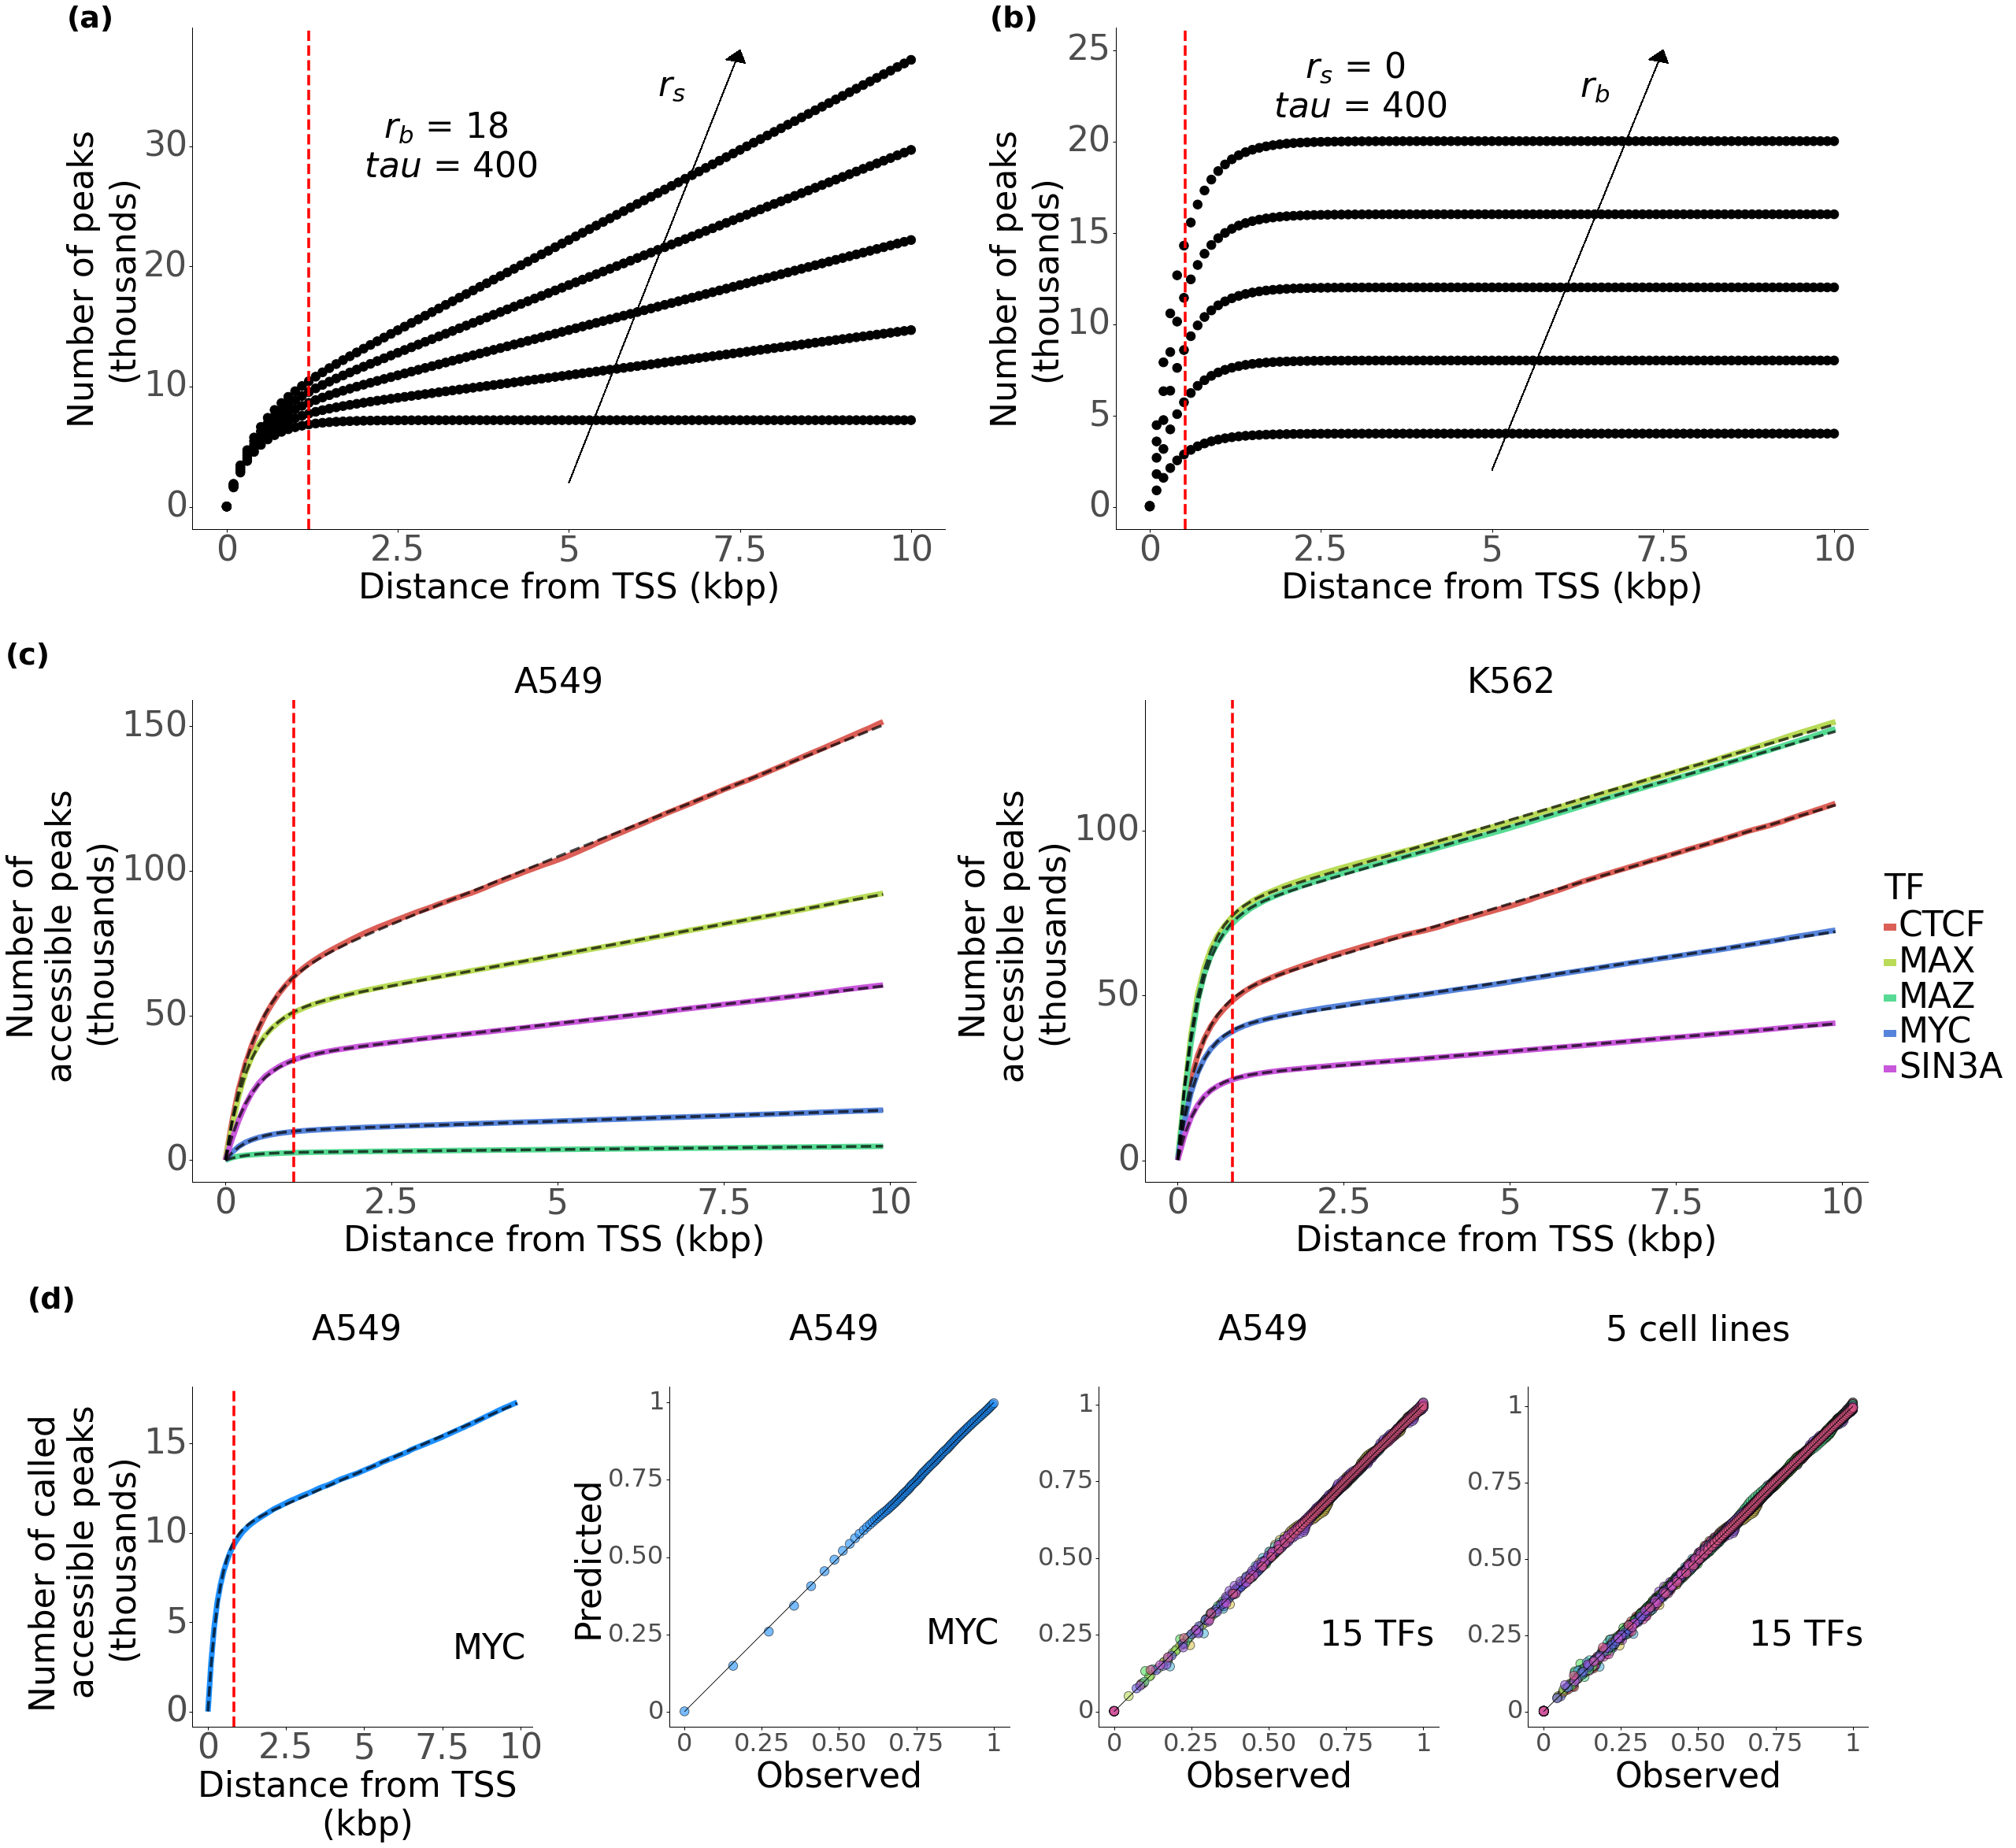

In [34]:
#Set figure sizes and format
ai = pw.load_ggplot(ai, figsize=(12,8))
aii = pw.load_ggplot(aii, figsize=(12,8))
bi = pw.load_ggplot(bi, figsize=(12,8))
bii = pw.load_ggplot(bii, figsize=(12,8))
ci = pw.load_ggplot(ci, figsize=(6,6))
cii = pw.load_ggplot(cii, figsize=(6,6))
ciii = pw.load_ggplot(ciii, figsize=(6,6))
civ = pw.load_ggplot(civ, figsize=(6,6))
c= ci + cii+ciii+ civ

#Set indices for each panel
ai.set_index('(a)',size = 38,fontweight="bold" )
aii.set_index('(b)',size = 38,fontweight="bold")
bi.set_index('(c)',size = 38,fontweight="bold")
bii.set_index(' ',size = 38,fontweight="bold")
c.set_index('(d)',size = 38,fontweight="bold")


fig3= (ai|aii)/(bi|bii)/c
fig3.savefig('../../Figures/Figure2.pdf')

